# Notebook 6 — National parametric benchmarks: Cox PH + Weibull AFT

Fits the two standard survival-regression baselines on the **same national
first-hit-poor dataset and the same seed-42 80/20 split** as the RSF
(`train_national_rsf.ipynb`), so all three models are directly comparable on
C-index, integrated Brier score, and time-dependent AUC.

**Inputs** (all produced by Notebook 4, `build_national_rsf_dataset.ipynb`):
- `us_parametric_data_clean.csv` — the drop-first (full-rank) design matrix Notebook 4
  writes specifically for parametric models (no dummy-variable trap).
- `us_rsf_data_clean.csv` — keys only, to assert both matrices hold the same bridges
  in the same row order (which makes the seed-42 split land on identical bridges).
- `us_rsf_metrics.json` — the RSF benchmark numbers + its IBS time grid (reused here
  so the Brier scores integrate over the same horizons).

**Outputs:** `us_parametric_metrics.json`, `us_cox_hazard_ratios.csv`,
`us_aft_coefficients.csv`, `us_cox_ph_test.csv` + `us_cox_ph_check.json`
(proportional-hazards assumption check), and `us_parametric_test_risk.csv`
(held-out risk scores consumed by `bootstrap_model_comparison.ipynb`).

**Method notes**
- lifelines cannot accept NaN, so features are filled with **train-only medians**,
  with the missingness kept as explicit 0/1 flags (one per distinct pattern, the
  18 climate columns share one mask; the `years_since_reconstruction` pattern is
  skipped because it duplicates `ever_reconstructed == 0`).
- Both fitters get a small ridge penalty (`penalizer = 0.01`): the design still has
  near-collinear dummy blocks, and at n ≈ 1M the shrinkage bias is negligible.
- The AFT arm standardizes continuous features with train statistics (its likelihood
  is poorly conditioned on raw scales, unlike `CoxPHFitter`, which normalizes
  internally), so continuous AFT coefficients in the CSV are per standard deviation.
- The **PH assumption is tested, not assumed** (scaled Schoenfeld residuals, rank
  transform), violations are inventoried and Cox hazard ratios are read as
  time-averaged effects; the model is deliberately not re-specified, since Cox here
  is a discriminative benchmark rather than an inferential endpoint.
- Reported coefficient claims pair **p-values with effect sizes**: at n ≈ 1M,
  significance alone is nearly free, so the metrics JSON counts how many p < 0.001
  features also move the hazard by more than 5% / 10%.
- What the comparison means: Cox assumes proportional hazards and linear effects;
  Weibull AFT additionally assumes a Weibull baseline. Their gap to the RSF measures
  how much national deck/sub/superstructure deterioration depends on interactions and
  non-linearities that a linear index cannot express — in exchange, Cox/AFT give
  interpretable hazard ratios / time ratios per feature.


In [1]:
# ── Configuration ─────────────────────────────────────────────────────────────
import json
import time
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sksurv.util import Surv
from sksurv.metrics import (concordance_index_censored, integrated_brier_score,
                            cumulative_dynamic_auc)
from lifelines import CoxPHFitter, WeibullAFTFitter

# Inputs from Notebook 4 (both matrices share row order)
DATA_PARAM  = Path("us_parametric_data_clean.csv")
DATA_RSF    = Path("us_rsf_data_clean.csv")          # keys only — split-parity check
RSF_METRICS = Path("us_rsf_metrics.json")            # benchmark + shared IBS grid

KEYS = ["STATE_FIPS", "STRUCTURE_NUMBER_008"]   # structure # is unique only WITHIN a state

SMOKE_TEST = False   # True -> small run on the Notebook 4/5 _smoke artifacts (see below)

# Small L2 ridge — near-collinear dummy/flag blocks; negligible bias at n ~ 1M.
PENALIZER = 0.01

AUC_HORIZONS = [25.0, 50.0, 75.0]   # years — the RSF evaluation's horizons

if SMOKE_TEST and Path("us_parametric_data_clean_smoke.csv").exists():
    # Smoke chain: exercise N4 -> N5 -> N6 on the small current-schema files.
    DATA_PARAM  = Path("us_parametric_data_clean_smoke.csv")
    DATA_RSF    = Path("us_rsf_data_clean_smoke.csv")
    RSF_METRICS = Path("us_rsf_metrics_smoke.json")
    print(f"SMOKE_TEST: reading Notebook 4/5 smoke artifacts ({DATA_PARAM})")

def out_path(name):
    """Output path; smoke runs get a _smoke suffix so real artifacts are never clobbered."""
    p = Path(name)
    return p.with_stem(p.stem + "_smoke") if SMOKE_TEST else p

OUT_METRICS  = out_path("us_parametric_metrics.json")
OUT_COX_HR   = out_path("us_cox_hazard_ratios.csv")
OUT_AFT_COEF = out_path("us_aft_coefficients.csv")

if not DATA_PARAM.exists():
    raise FileNotFoundError(
        f"{DATA_PARAM} not found — it is produced by build_national_rsf_dataset.ipynb (Notebook 4).")

print(f"config OK — smoke={SMOKE_TEST}, penalizer={PENALIZER}")


config OK — smoke=False, penalizer=0.01


In [2]:
# ── Typed load (mirrors train_national_rsf cell 3) + split-parity check ───────
cols = pd.read_csv(DATA_PARAM, nrows=0).columns
dtypes = {c: "float32" for c in cols}
dtypes.update({k: str for k in KEYS})
dtypes["event"] = "int8"
df = pd.read_csv(DATA_PARAM, dtype=dtypes)
for k in KEYS:
    df[k] = df[k].str.strip()

# Same row order as the RSF matrix -> the seed-42 split lands on the same test bridges.
rsf_keys = pd.read_csv(DATA_RSF, usecols=KEYS, dtype=str)[KEYS]
for k in KEYS:
    rsf_keys[k] = rsf_keys[k].str.strip()
assert len(df) == len(rsf_keys) and (df[KEYS].to_numpy() == rsf_keys.to_numpy()).all(), \
    "parametric matrix rows do not line up with the RSF matrix — split would not be comparable"
del rsf_keys

# Subsample only under smoke against the FULL matrix; the N4 smoke matrices are used
# whole to keep the split aligned with N5 and the leakage/bootstrap notebooks.
if SMOKE_TEST and "smoke" not in DATA_PARAM.stem and len(df) > 20_000:
    df = df.sample(n=20_000, random_state=42).reset_index(drop=True)
    print(f"SMOKE_TEST: subsampled to {len(df):,} bridges")

assert (df["time"] > 0).all(), "non-positive survival times — Notebook 4 should have dropped these"

y   = Surv.from_arrays(event=df["event"].astype(bool).to_numpy(),
                       time=df["time"].astype("float64").to_numpy())
ids = df[KEYS].copy()

# bridge_age == time here — must drop.
X = df.drop(columns=["event", "time", "bridge_age"] + KEYS)

leak = [c for c in X.columns if "_COND_" in c or c == "OPEN_CLOSED_POSTED_041"]
assert not leak, f"leakage columns present: {leak}"
assert X.select_dtypes(exclude="number").shape[1] == 0, "non-numeric feature columns in X"

del df
print(f"X: {X.shape[0]:,} bridges x {X.shape[1]} features   "
      f"event rate: {y['event'].mean()*100:.1f}%   NaN share: {X.isna().mean().mean()*100:.1f}%")


X: 973,905 bridges x 238 features   event rate: 29.3%   NaN share: 1.5%


In [3]:
# ── Missingness flags + identical 80/20 split + train-median imputation ───────
# lifelines needs complete data: encode missingness as 0/1 flags (one per distinct
# pattern), then impute with TRAIN medians.
na_cols = X.columns[X.isna().any()].tolist()

never_reconstructed = (X["ever_reconstructed"] == 0).to_numpy().astype("int8")
seen, flags = set(), {}
for c in na_cols:
    m = X[c].isna().to_numpy()
    key = m.tobytes()
    if key in seen:
        continue                      # duplicate pattern -> one flag
    seen.add(key)
    f = m.astype("int8")
    if (f == never_reconstructed).all():
        continue                      # already encoded by ever_reconstructed
    flags[c + "_missing"] = f
X = pd.concat([X, pd.DataFrame(flags, index=X.index)], axis=1)
print(f"{len(na_cols)} columns with NaN -> {len(flags)} distinct missingness flags")

X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
    X, y, ids, test_size=0.2, random_state=42)

med = X_train[na_cols].median()
X_train = X_train.fillna(med)
X_test  = X_test.fillna(med)
assert not X_train.isna().any().any() and not X_test.isna().any().any()

# Train-constant columns: no signal, and they wreck the optimizer's scaling.
const = X_train.columns[(X_train.max(axis=0) == X_train.min(axis=0)).to_numpy()].tolist()
if const:
    X_train, X_test = X_train.drop(columns=const), X_test.drop(columns=const)
    print(f"dropped {len(const)} train-constant columns: {const[:8]}{'...' if len(const) > 8 else ''}")

print(f"train: {len(X_train):,}   test: {len(X_test):,}   features: {X_train.shape[1]}")


45 columns with NaN -> 30 distinct missingness flags


dropped 2 train-constant columns: ['inventory_rating_insignificant_load', 'bridge_age_negative_flag']
train: 779,124   test: 194,781   features: 266


In [4]:
# ── Cox proportional hazards ──────────────────────────────────────────────────
train_df = X_train.assign(time=y_train["time"], event=y_train["event"].astype("int8"))

t0 = time.time()
cph = CoxPHFitter(penalizer=PENALIZER)
cph.fit(train_df, duration_col="time", event_col="event", show_progress=True)
cox_fit_s = time.time() - t0

cox_risk = cph.predict_partial_hazard(X_test).to_numpy()   # higher = riskier
cox_ci = concordance_index_censored(y_test["event"], y_test["time"], cox_risk)[0]
print(f"\nCox PH: test C-index {cox_ci:.4f}   fit {cox_fit_s:.0f}s   "
      f"({len(cph.params_)} coefficients)")

hr = cph.summary[["coef", "exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]]
hr = hr.sort_values("coef", key=np.abs, ascending=False)
hr.to_csv(OUT_COX_HR)
print(f"hazard ratios -> {OUT_COX_HR}")
hr.head(10)


C:\Users\Joshu\AppData\Local\Temp\ipykernel_23720\1545030503.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df = X_train.assign(time=y_train["time"], event=y_train["event"].astype("int8"))


C:\Users\Joshu\Documents\GitHub\Bridge_project_pt2\.venv\Lib\site-packages\lifelines\utils\__init__.py:1100: ConvergenceWarning: Column(s) ['TOLL_020_Other'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


Iteration 1: norm_delta = 1.80e+00, step_size = 0.9500, log_lik = -2810551.30362, newton_decrement = 1.70e+05, seconds_since_start = 3.9


Iteration 2: norm_delta = 1.06e+00, step_size = 0.9500, log_lik = -2644488.78962, newton_decrement = 3.62e+04, seconds_since_start = 7.9


Iteration 3: norm_delta = 2.20e-01, step_size = 0.9500, log_lik = -2605763.58860, newton_decrement = 2.49e+03, seconds_since_start = 11.8


...

Iteration 9: norm_delta = 1.52e-04, step_size = 1.0000, log_lik = -2602076.51366, newton_decrement = 8.29e-03, seconds_since_start = 35.5


Iteration 10: norm_delta = 1.73e-06, step_size = 1.0000, log_lik = -2602076.50531, newton_decrement = 1.07e-06, seconds_since_start = 39.5


Iteration 11: norm_delta = 2.24e-10, step_size = 1.0000, log_lik = -2602076.50531, newton_decrement = 1.78e-14, seconds_since_start = 43.4
Convergence success after 11 iterations.



Cox PH: test C-index 0.8830   fit 53s   (266 coefficients)
hazard ratios -> us_cox_hazard_ratios.csv


,coef,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
covariate,,,,,
BASE_HWY_NETWORK_012_missing,1.938223,6.946393,6.848418,7.045769,0.000000e+00
MAINTENANCE_70,-1.336671,0.262719,0.218348,0.316106,1.581180e-45
MAINTENANCE_68,-1.321902,0.266628,0.192574,0.369158,1.681687e-15
STRUCTURE_TYPE_043B_8,1.173961,3.234781,2.700352,3.874978,3.457577e-37
MAINTENANCE_64,-1.066364,0.344258,0.324059,0.365716,8.402143e-262
MAINTENANCE_66,-1.063726,0.345167,0.308223,0.386540,9.659049e-76
MAINTENANCE_Other,-0.934339,0.392845,0.293318,0.526144,3.655627e-10
DECK_PROTECTION_1,-0.910263,0.402418,0.391426,0.413720,0.000000e+00
MAINTENANCE_32,-0.893027,0.409414,0.337907,0.496054,7.636612e-20


C:\Users\Joshu\Documents\GitHub\Bridge_project_pt2\.venv\Lib\site-packages\lifelines\utils\__init__.py:1100: ConvergenceWarning: Column(s) ['TOLL_020_Other'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


proportional_hazard_test on stratified (state x event) 99,999-row training subsample (29,265 events), identical refit — the full-train test is quadratic in events (~19 h measured extrapolation)  (1230s)
covariates tested: 266   PH violated at p<0.05: 86   at p<0.001: 42

worst offenders (largest test statistic):
                   covariate  test_statistic             p
              YEAR_BUILT_027      488.472033 3.063948e-108
BASE_HWY_NETWORK_012_missing      114.334329  1.100902e-26
              SURFACE_TYPE_1      107.081961  4.271343e-25
                    STATE_47       87.524989  8.322169e-21
              SURFACE_TYPE_7       56.819487  4.777089e-14
                 DECK_TYPE_9       52.898435  3.512493e-13
        BASE_HWY_NETWORK_012       49.246968  2.256819e-12
          SCOUR_CRITICAL_113       45.107470  1.865126e-11
                 DECK_TYPE_6       43.167062  5.025969e-11
     LAT_UND_MT_055B_missing       40.307491  2.169754e-10

per-covariate table -> us_cox_ph_tes

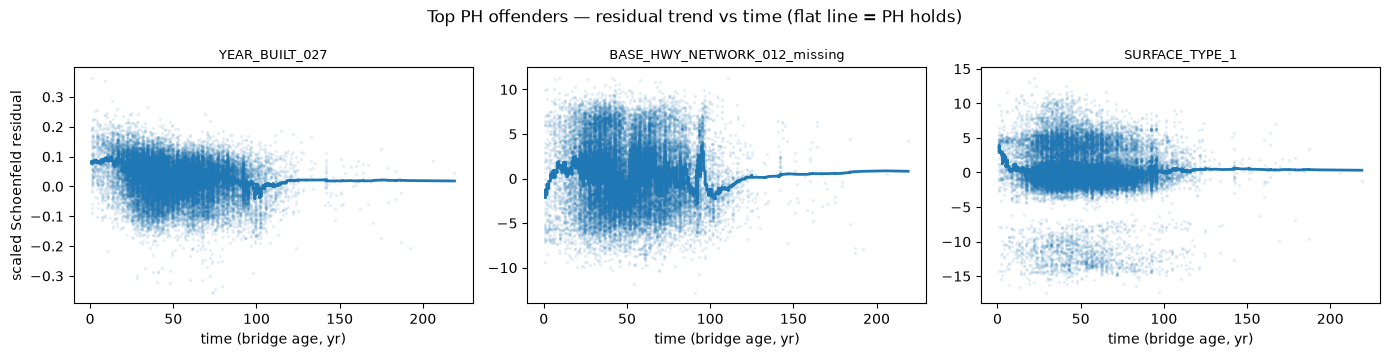

In [5]:
# ── Proportional-hazards check (scaled Schoenfeld residuals, rank transform) ──
# proportional_hazard_test is ~quadratic in events (full train ~19 h), so it refits
# Cox on a stratified (state x event) PH_MAX_ROWS subsample. Reported as a caveat,
# not a remodel: at this n most real time-varying effects are detectable, so the
# output is the violation inventory and worst offenders. Runs before the AFT cell
# (residual matrix + train_df is the memory peak).
from lifelines.statistics import proportional_hazard_test

PH_MAX_ROWS  = 100_000
OUT_PH_TEST  = out_path("us_cox_ph_test.csv")
OUT_PH_CHECK = out_path("us_cox_ph_check.json")

t0 = time.time()
if len(train_df) > PH_MAX_ROWS:
    strat = pd.DataFrame({"state": ids_train["STATE_FIPS"].to_numpy(),
                          "event": y_train["event"]})
    pos = (strat.groupby(["state", "event"], group_keys=False)
                .sample(frac=min(1.0, PH_MAX_ROWS / len(strat)),
                        random_state=42)).index.to_numpy()
    ph_df = train_df.iloc[pos]
    ph_model = CoxPHFitter(penalizer=PENALIZER)
    ph_model.fit(ph_df, duration_col="time", event_col="event")
    ph_scope = (f"stratified (state x event) {len(ph_df):,}-row training subsample "
                f"({int(ph_df['event'].sum()):,} events), identical refit — the "
                "full-train test is quadratic in events (~19 h measured extrapolation)")
else:
    ph_model, ph_df = cph, train_df
    ph_scope = f"full training set (n={len(ph_df):,})"
ph_res = proportional_hazard_test(ph_model, ph_df, time_transform="rank")
print(f"proportional_hazard_test on {ph_scope}  ({time.time()-t0:.0f}s)")

ph_tbl = ph_res.summary.copy()
if isinstance(ph_tbl.index, pd.MultiIndex):          # (variable, time_transform) when >1 transform
    ph_tbl.index = ph_tbl.index.get_level_values(0)
ph_tbl = (ph_tbl.rename_axis("covariate").reset_index()
                .sort_values("test_statistic", ascending=False).reset_index(drop=True))
ph_tbl.to_csv(OUT_PH_TEST, index=False)

n_cov  = len(ph_tbl)
n_p05  = int((ph_tbl["p"] < 0.05).sum())
n_p001 = int((ph_tbl["p"] < 0.001).sum())
top10 = ph_tbl.head(10)[["covariate", "test_statistic", "p"]]
print(f"covariates tested: {n_cov}   PH violated at p<0.05: {n_p05}   at p<0.001: {n_p001}")
print("\nworst offenders (largest test statistic):")
print(top10.to_string(index=False))

ph_summary = {
    "scope": ph_scope,
    "time_transform": "rank",
    "n_covariates": n_cov,
    "n_violating_p05": n_p05,
    "n_violating_p001": n_p001,
    "top10_offenders": [
        {"covariate": r.covariate, "test_statistic": round(float(r.test_statistic), 1),
         "p": float(r.p)} for r in top10.itertuples()],
    "interpretation": ("At this n, statistically detectable PH violations are expected for "
                       "most real time-varying effects; Cox is reported as a discriminative "
                       "benchmark and its hazard ratios read as time-averaged effects."),
}
OUT_PH_CHECK.write_text(json.dumps(ph_summary, indent=2))
print(f"\nper-covariate table -> {OUT_PH_TEST}   summary -> {OUT_PH_CHECK}")

# Scaled-Schoenfeld vs time for the top-3 offenders (check_assumptions() would plot
# all ~hundreds of offenders).
try:
    import matplotlib.pyplot as plt
    top3 = ph_tbl["covariate"].head(3).tolist()
    resid = ph_model.compute_residuals(ph_df, kind="scaled_schoenfeld")
    t_ev = ph_df.loc[resid.index, "time"].to_numpy()
    order = np.argsort(t_ev)
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
    for ax, c in zip(axes, top3):
        r = resid[c].to_numpy()[order]
        ax.scatter(t_ev[order], r, s=2, alpha=0.08)
        w = max(101, (len(r) // 200) | 1)                      # odd centered window
        ax.plot(t_ev[order], pd.Series(r).rolling(w, center=True, min_periods=w // 2).median(),
                lw=2)
        ax.set_title(c, fontsize=9)
        ax.set_xlabel("time (bridge age, yr)")
    axes[0].set_ylabel("scaled Schoenfeld residual")
    fig.suptitle("Top PH offenders — residual trend vs time (flat line = PH holds)")
    fig.tight_layout()
    plt.show()
    del resid
except MemoryError:
    print("residual plots skipped: scaled-Schoenfeld matrix did not fit in RAM "
          "(the test table above is unaffected)")

In [6]:
# ── Weibull AFT (same design, same split) ─────────────────────────────────────
# AFT fitters don't normalize internally (Cox does), and raw scales (ADT ~ 1e5 vs
# 0/1 dummies) stall the optimizer — standardize continuous columns on TRAIN stats.
# Saved continuous coefficients are per-SD.
is_binary = ((X_train == 0) | (X_train == 1)).all()
cont = X_train.columns[~is_binary]
mu, sd = X_train[cont].mean(), X_train[cont].std()
Xtr_aft, Xte_aft = X_train.copy(), X_test.copy()
Xtr_aft[cont] = (Xtr_aft[cont] - mu) / sd
Xte_aft[cont] = (Xte_aft[cont] - mu) / sd
train_df_aft = Xtr_aft.assign(time=y_train["time"], event=y_train["event"].astype("int8"))

t0 = time.time()
aft = WeibullAFTFitter(penalizer=PENALIZER)
# SLSQP needs more than its default 200-iteration cap here (converges under 2000).
aft.fit(train_df_aft, duration_col="time", event_col="event", show_progress=True,
        fit_options={"maxiter": 2000})
aft_fit_s = time.time() - t0

# AFT predicts survival time: longer predicted survival = lower risk -> negate.
aft_median = aft.predict_median(Xte_aft).to_numpy(dtype="float64")
aft_ci = concordance_index_censored(y_test["event"], y_test["time"], -aft_median)[0]
print(f"\nWeibull AFT: test C-index {aft_ci:.4f}   fit {aft_fit_s:.0f}s   "
      f"({len(cont)} continuous features standardized)")

aft.summary.to_csv(OUT_AFT_COEF)
print(f"coefficients -> {OUT_AFT_COEF}")


Optimization terminated successfully    (Exit mode 0)
            Current function value: 1.3461266951563886
            Iterations: 227
            Function evaluations: 459
            Gradient evaluations: 227
     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 1.3461266951563886
           x: [-1.051e-03 -4.838e-04 ...  4.419e+00  1.737e+00]
         nit: 227
         jac: [-4.663e-06 -9.817e-07 ...  6.684e-07 -9.538e-07]
        nfev: 459
        njev: 227
 multipliers: []



Weibull AFT: test C-index 0.8833   fit 311s   (43 continuous features standardized)
coefficients -> us_aft_coefficients.csv


In [7]:
# ── Test-risk handoff -> us_parametric_test_risk.csv ──────────────────────────
# Per-bridge held-out risk for both parametric models, consumed by
# bootstrap_model_comparison.ipynb. AFT risk is -predict_median (higher = riskier).
OUT_TEST_RISK = out_path("us_parametric_test_risk.csv")
pd.DataFrame({
    "STATE_FIPS": ids_test["STATE_FIPS"].to_numpy(),
    "STRUCTURE_NUMBER_008": ids_test["STRUCTURE_NUMBER_008"].to_numpy(),
    "event": y_test["event"].astype(int),
    "time": y_test["time"],
    "cox_risk": cox_risk,
    "aft_risk": -aft_median,
}).to_csv(OUT_TEST_RISK, index=False)
print(f"saved {OUT_TEST_RISK} ({len(cox_risk):,} test bridges)")

saved us_parametric_test_risk.csv (194,781 test bridges)


In [8]:
# ── Effect sizes vs p-values ──────────────────────────────────────────────────
# At n ~ 1M significance is cheap, so pair it with HR materiality cutoffs (>5% and
# >10% from 1.0). The README reports the paired counts.
p001 = hr["p"] < 0.001
outside_5  = p001 & ~hr["exp(coef)"].between(0.95, 1.05)
outside_10 = p001 & ~hr["exp(coef)"].between(0.90, 1.10)

top_material = hr[outside_10].head(10)   # hr is sorted by |coef| already
print(f"features: {len(hr)}   significant at p<0.001: {int(p001.sum())}")
print(f"  of those, HR outside [0.95, 1.05]: {int(outside_5.sum())}")
print(f"  of those, HR outside [0.90, 1.10]: {int(outside_10.sum())}")
print(f"  (i.e. {int(p001.sum()) - int(outside_5.sum())} 'significant' features move the "
      f"hazard by less than 5%)")
print("\nlargest material effects (p<0.001, |HR-1| > 10%):")
print(top_material[["exp(coef)", "p"]].round(4).to_string())

effect_size_summary = {
    "n_features": int(len(hr)),
    "n_significant_p001": int(p001.sum()),
    "n_p001_hr_outside_5pct": int(outside_5.sum()),
    "n_p001_hr_outside_10pct": int(outside_10.sum()),
    "top_material_effects": [
        {"feature": idx, "hazard_ratio": round(float(r["exp(coef)"]), 3), "p": float(r["p"])}
        for idx, r in top_material.iterrows()],
}

features: 266   significant at p<0.001: 204
  of those, HR outside [0.95, 1.05]: 168
  of those, HR outside [0.90, 1.10]: 155
  (i.e. 36 'significant' features move the hazard by less than 5%)

largest material effects (p<0.001, |HR-1| > 10%):
                              exp(coef)    p
covariate                                   
BASE_HWY_NETWORK_012_missing     6.9464  0.0
MAINTENANCE_70                   0.2627  0.0
MAINTENANCE_68                   0.2666  0.0
STRUCTURE_TYPE_043B_8            3.2348  0.0
MAINTENANCE_64                   0.3443  0.0
MAINTENANCE_66                   0.3452  0.0
MAINTENANCE_Other                0.3928  0.0
DECK_PROTECTION_1                0.4024  0.0
MAINTENANCE_32                   0.4094  0.0
SERVICE_ON_042A_2                0.4213  0.0


In [9]:
# ── IBS + time-dependent AUC on the RSF's own evaluation grid ─────────────────
grid = np.asarray(json.loads(RSF_METRICS.read_text())["ibs_time_grid"], dtype=float)
lo = max(float(y_test["time"].min()), float(y_train["time"].min()))
hi = min(float(y_test["time"].max()), float(y_train["time"].max()))
grid = grid[(grid > lo) & (grid < hi)]

def surv_matrix(model, X, times):
    """(n, n_times) survival probabilities, chunked to keep float64 blocks small."""
    out = []
    for i in range(0, len(X), 50_000):
        out.append(model.predict_survival_function(X.iloc[i:i + 50_000], times=times).to_numpy().T)
    return np.vstack(out)

ibs, auc = {}, {}
for name, model, Xte in [("cox_ph", cph, X_test), ("weibull_aft", aft, Xte_aft)]:
    S = surv_matrix(model, Xte, grid)
    ibs[name] = float(integrated_brier_score(y_train, y_test, S, grid))
    risk_h = 1.0 - surv_matrix(model, Xte, np.asarray(AUC_HORIZONS))
    a, mean_a = cumulative_dynamic_auc(y_train, y_test, risk_h, AUC_HORIZONS)
    auc[name] = {"by_horizon": {f"{int(h)}yr": round(float(v), 4) for h, v in zip(AUC_HORIZONS, a)},
                 "mean": round(float(mean_a), 4)}
    print(f"{name}: IBS {ibs[name]:.4f}   AUC {auc[name]['by_horizon']}   mean {auc[name]['mean']:.4f}")


cox_ph: IBS 0.0565   AUC {'25yr': 0.9523, '50yr': 0.932, '75yr': 0.9637}   mean 0.9515


weibull_aft: IBS 0.0567   AUC {'25yr': 0.9537, '50yr': 0.9326, '75yr': 0.9608}   mean 0.9502


In [10]:
# ── Comparison vs the RSF benchmark + persist metrics ─────────────────────────
rsf = json.loads(RSF_METRICS.read_text())
rows = [
    ("RSF (train_national_rsf)", rsf["c_index_test"], rsf["integrated_brier_score"],
     rsf["auc_mean"], rsf["fit_seconds"]),
    ("Cox PH", cox_ci, ibs["cox_ph"], auc["cox_ph"]["mean"], cox_fit_s),
    ("Weibull AFT", aft_ci, ibs["weibull_aft"], auc["weibull_aft"]["mean"], aft_fit_s),
]
print(f"{'model':<26} {'C-index':>8} {'IBS':>7} {'mean AUC':>9} {'fit (s)':>8}")
for n, c, b, a, s in rows:
    print(f"{n:<26} {c:>8.4f} {b:>7.4f} {a:>9.4f} {s:>8.0f}")

metrics = {
    "generated_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    "smoke_test": SMOKE_TEST,
    "n_bridges": int(len(X_train) + len(X_test)),
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
    "n_features": int(X_train.shape[1]),
    "penalizer": PENALIZER,
    "imputation": "train-median + deduplicated 0/1 missingness flags",
    "cox_ph": {
        "c_index_test": round(float(cox_ci), 4),
        "integrated_brier_score": round(ibs["cox_ph"], 4),
        "auc_by_horizon": auc["cox_ph"]["by_horizon"],
        "auc_mean": auc["cox_ph"]["mean"],
        "fit_seconds": round(cox_fit_s, 1),
    },
    "weibull_aft": {
        "c_index_test": round(float(aft_ci), 4),
        "integrated_brier_score": round(ibs["weibull_aft"], 4),
        "auc_by_horizon": auc["weibull_aft"]["by_horizon"],
        "auc_mean": auc["weibull_aft"]["mean"],
        "fit_seconds": round(aft_fit_s, 1),
    },
    "rsf_reference": {
        "c_index_test": rsf["c_index_test"],
        "integrated_brier_score": rsf["integrated_brier_score"],
        "auc_mean": rsf["auc_mean"],
        "source": str(RSF_METRICS),
    },
    "ph_check": ph_summary,                       # full table in us_cox_ph_test.csv
    "cox_effect_size_summary": effect_size_summary,
}
OUT_METRICS.write_text(json.dumps(metrics, indent=2))
print(f"\nmetrics -> {OUT_METRICS}")


model                       C-index     IBS  mean AUC  fit (s)
RSF (train_national_rsf)     0.7526  0.0761    0.9383     2345
Cox PH                       0.8830  0.0565    0.9515       53
Weibull AFT                  0.8833  0.0567    0.9502      311

metrics -> us_parametric_metrics.json


In [11]:
# ── Output verification ───────────────────────────────────────────────────────
m = json.loads(OUT_METRICS.read_text())
for k in ("cox_ph", "weibull_aft"):
    assert 0.5 < m[k]["c_index_test"] < 1.0, (k, m[k])
    assert 0.0 < m[k]["integrated_brier_score"] < 0.25, (k, m[k])
    assert 0.5 < m[k]["auc_mean"] <= 1.0, (k, m[k])
hr_csv = pd.read_csv(OUT_COX_HR, index_col=0)
assert len(hr_csv) == X_train.shape[1] and {"coef", "exp(coef)", "p"} <= set(hr_csv.columns)
assert pd.read_csv(OUT_AFT_COEF).shape[0] >= X_train.shape[1]

# revision additions: PH check + effect sizes persisted, risk handoff intact
es = m["cox_effect_size_summary"]
assert (es["n_p001_hr_outside_10pct"] <= es["n_p001_hr_outside_5pct"]
        <= es["n_significant_p001"] <= es["n_features"])
assert m["ph_check"]["n_covariates"] > 0 and OUT_PH_TEST.exists() and OUT_PH_CHECK.exists()
risk_rows = len(pd.read_csv(OUT_TEST_RISK, usecols=["event"]))
assert risk_rows == len(X_test), "test-risk handoff row count != test split"

print("VERIFICATION PASSED —",
      f"Cox C {m['cox_ph']['c_index_test']:.4f},",
      f"AFT C {m['weibull_aft']['c_index_test']:.4f},",
      f"RSF reference {m['rsf_reference']['c_index_test']:.4f};",
      f"PH violations {m['ph_check']['n_violating_p001']}/{m['ph_check']['n_covariates']} at p<0.001;",
      f"material effects {es['n_p001_hr_outside_10pct']}/{es['n_significant_p001']} significant")


VERIFICATION PASSED — Cox C 0.8830, AFT C 0.8833, RSF reference 0.7526; PH violations 42/266 at p<0.001; material effects 155/204 significant
